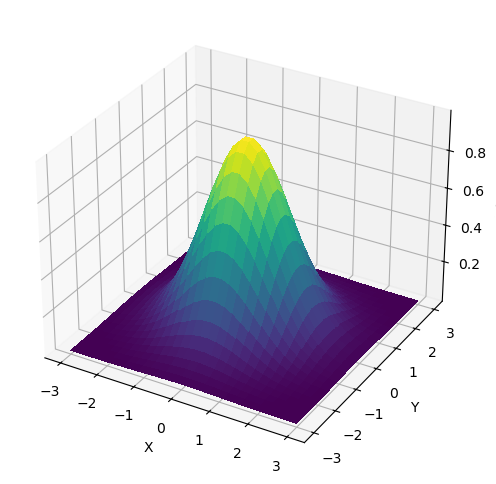

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define a 2D Gaussian function
def gaussian_2d(x, y, mu_x=0, mu_y=0, sigma_x=1, sigma_y=1):
    return np.exp(-((x - mu_x)**2 / (2 * sigma_x**2) + (y - mu_y)**2 / (2 * sigma_y**2)))

# Create a grid
x = np.linspace(-3, 3, 30)
y = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(x, y)
Z = gaussian_2d(X, Y)

# Plot the 3D surface
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none',antialiased=False)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Height')
plt.show()


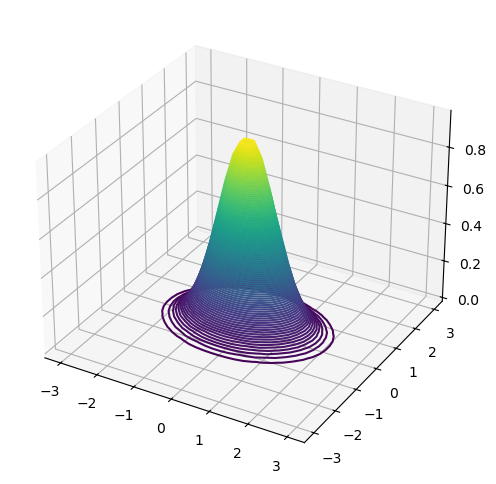

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D data grid
Nx, Ny, Nz = 30, 30, 30  # Grid size
x = np.linspace(-3, 3, Nx)
y = np.linspace(-3, 3, Ny)
z = np.linspace(-3, 3, Nz)
X, Y = np.meshgrid(x, y, indexing='ij')
X, Z = np.meshgrid(x, z, indexing='ij')
# # Define a 3D Gaussian function as example data
data_2d = np.exp(-(X**2 + Y**2 + Z**2))

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none',antialiased=False)

levels = np.linspace(np.min(data_2d), np.max(data_2d), 100)
contour = ax.contour3D(X, Y, data_2d, Z, levels=levels, cmap='viridis')#,antialiased=False)

In [166]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=netCDF['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=netCDF.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=netCDF['time']
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF
# data=netCDF.isel(time=np.arange(0,140+1))
# parcel=parcel.isel(time=np.arange(0,140+1))
res='1km'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

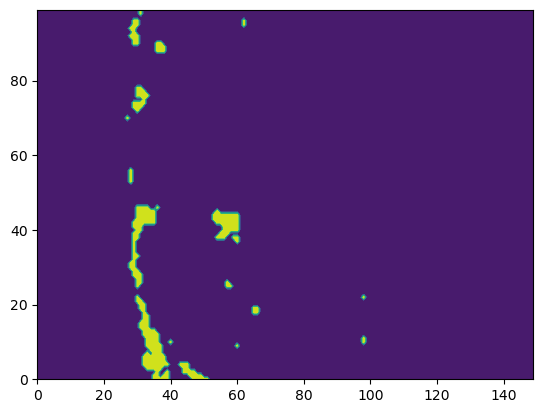

In [194]:
fraction=2/8
def cloud_array(t):
    qc_t=data['qc'].isel(time=t)
    qi_t=data['qi'].isel(time=t)
    qcqi_t=qc_t+qi_t
    
    binary_t=np.zeros_like(qc_t)
    where=np.where(qcqi_t>=1e-5)
    binary_t[where]=1
    
    out=binary_t[0:10,0:100, int(512*fraction):] 
    out=out[:,:,0:150]
    # out=binary_t[:,:,:] #uncomment for full domain
    
    plt.contourf(out[9,:,:]) 
    return out
clouds=cloud_array(101)

In [195]:
clouds=clouds[:,30:40,0:40]

TypeError: Input z must be 2D, not 3D

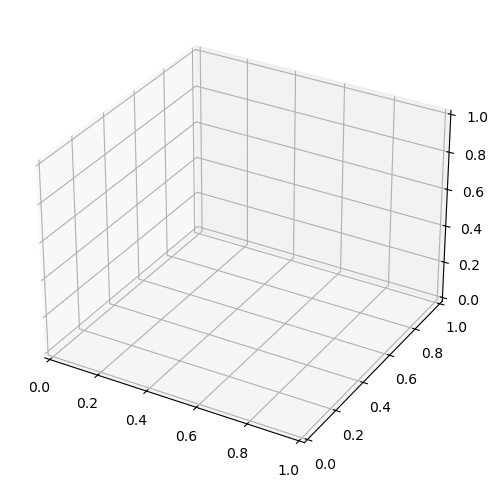

In [207]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D data grid
Nz,Ny,Nx=clouds.shape
x = np.linspace(0, Nx, Nx)
y = np.linspace(0, Ny, Ny)
z = np.linspace(0, Nz, Nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
data_3d=clouds

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
# ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none',antialiased=False)

levels = np.linspace(np.min(data_3d), np.max(data_3d), 50)
contour = ax.contour3D(X, Y, Z, data_3d, levels=levels, cmap='viridis')#,antialiased=False)